# Classification example (multi.output)


In [1]:
import shap
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml



# Regression example (one output)

In [2]:

import shap
import sklearn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd

# Load dataset
data = pd.read_csv("data/bcn_noise_class_ml_subsample.csv")
data = data.dropna()
#print(data)

X = data.drop(columns=['road_id','noise_day','noise_evening', 'noise_night']) # keep only features
y = data['noise_day']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Train a simple linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [3]:
# Use k-means to summarise background dataset for KernelExplainer
background = shap.kmeans(X_train, 50)  # 50 clusters

# Create KernelExplainer with summarized background
explainer = shap.KernelExplainer(model.predict, background)

shap_values = explainer.shap_values(X_train.iloc[:100, :])

c:\Users\ecori\miniconda3\envs\data-encoding\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


  0%|          | 0/100 [00:00<?, ?it/s]

Summary pot (dot style)

What the Plot Shows
Y-axis: Features, ordered from most to least important (based on mean absolute SHAP values).

Each dot: A single data point’s SHAP value for that feature.

X-axis: SHAP value — the contribution of that feature to pushing the prediction higher (positive) or lower (negative).

Colour of each dot: The original feature value (e.g., blue for low values, red for high values).

How to Interpret It
A dot far to the right means the feature strongly pushes the prediction higher for that sample.

A dot far to the left means the feature strongly pushes the prediction lower.

Colour gradients show how feature value relates to its effect:

If red dots are mostly right, high values increase predictions.

If red dots are mostly left, high values decrease predictions.

The vertical spread of dots per feature shows variation in effect across samples.

Overlapping dots form dense regions, indicating many similar SHAP values.

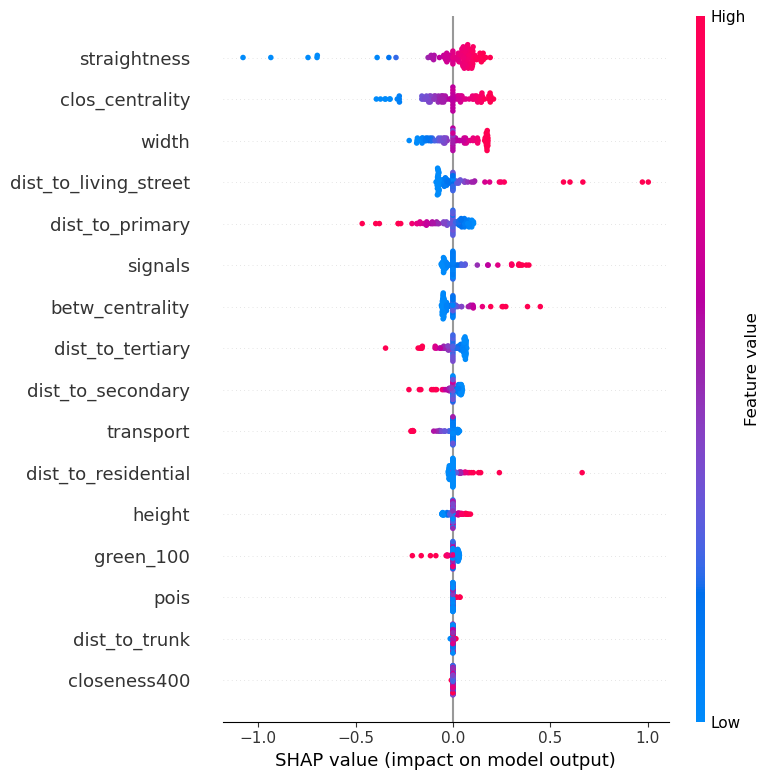

In [4]:

# Summary plot
shap.summary_plot(shap_values, X_train.iloc[:100, :], plot_type="dot")


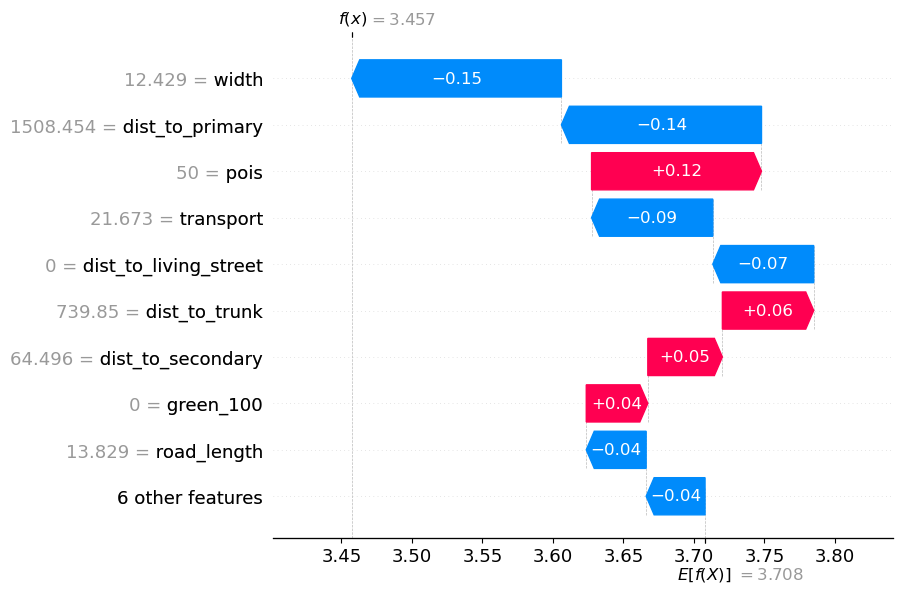

In [ ]:
# Waterfall plot for first instance
shap.plots.waterfall(shap.Explanation(values=shap_values[0],
                                     base_values=explainer.expected_value,
                                     data=X_train.iloc[0, :]))

Force plot

What the Force Plot Shows
The base value (usually in the center) is the average model output over the background dataset — think of it as the baseline prediction before seeing any features.

The final prediction for the instance is shown at the right (or left, depending on value).

Arrows or colored bars represent feature contributions pushing the prediction up (towards higher values, often red) or down (towards lower values, often blue).

The length of each arrow corresponds to the magnitude of the feature’s impact.

Features are stacked to show cumulative effect from the base value to the prediction.



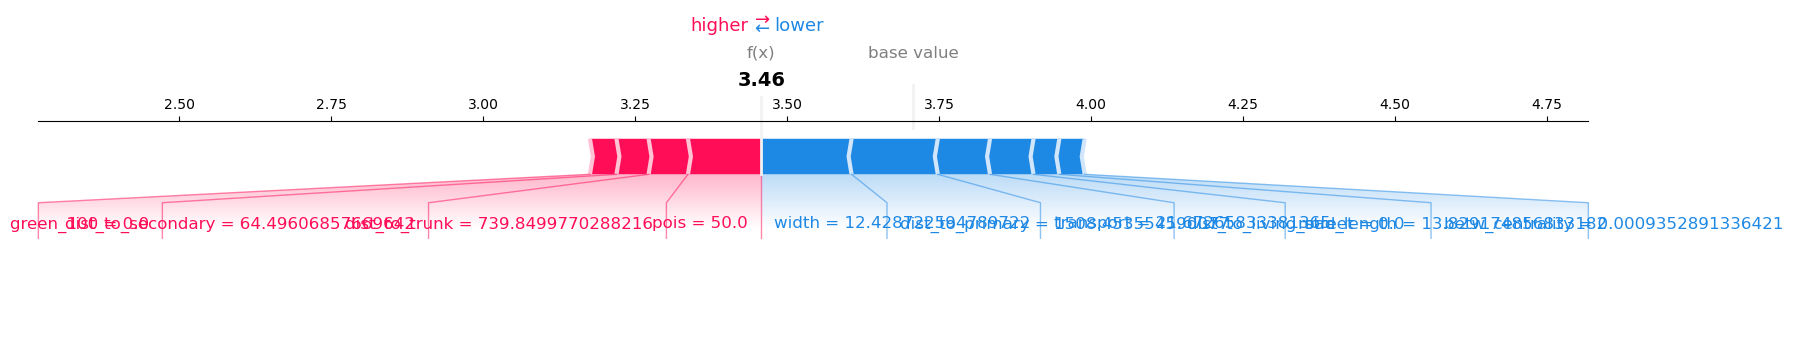

In [ ]:
# Create the force plot for the first instance
shap.force_plot(
    explainer.expected_value,          # base value
    shap_values[0],                    # SHAP values for first  instance
    X_train.iloc[0, :],             # feature values for first  instance
    matplotlib=True                    # plot inline with matplotlib
)